In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import time
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from datasets import load_dataset

In [4]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "qos.py").exists() and (ROOT.parent / "qos.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Root found:", ROOT)
print("qos.py exists:", (ROOT / "qos.py").exists())

Root found: /Users/mbayietendong/quantum-oracle-sketching
qos.py exists: True


In [5]:
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
import numpy as np

SEED = 42
key = random.PRNGKey(SEED)

print("Setup complete. Key:", key)

Setup complete. Key: [ 0 42]


In [6]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("leannmlindsey/GUE", "prom_core_notata")

In [7]:
test_split = ds["test"]

df_test = test_split.to_pandas()
print(df_test.head())

                                            sequence  label
0  GCGGTTGTAGTCTGAACTGTATGGTCCCTCCGCAGCCTCGGGATTG...      0
1  CTCTTGCCTTCCGGCCCGGCGCCCGATTTCCGCCTTCCGACCCAGC...      1
2  ACAGTGACTCGGTGGCACCCTGGACTTTTGCTGACAGCTCACAATT...      1
3  CCTTGGAAGTGGGACGGGGTCCTGCAGCGGGTCCTTCCGGCGGGTG...      1
4  GCACCCAAACCCTCGGCGGACAGCGGAGCCAGTGGTAGCCGCACGG...      1


In [8]:
seq_df = df_test
print(seq_df.shape)

seq_df_test = df_test
print(seq_df_test.shape)


(5307, 2)
(5307, 2)


In [17]:
seq_df = seq_df_test.reset_index(drop=True)
seq_df["label"].value_counts()

label
1    2659
0    2648
Name: count, dtype: int64

There are 11 more promoters than non promoters, so basically even. 
- look back into this to see if it may through off classifying results 

In [9]:
K = 4
ALL_KMERS = ["".join(p) for p in itertools.product("ACGT", repeat=K)]
len(ALL_KMERS)

KMER_INDEX = {kmer: idx for idx, kmer in enumerate(ALL_KMERS)}

def kmer_counts(seq):
    vec = np.zeros(len(ALL_KMERS))
    for i in range(len(seq) - K + 1):
        idx = KMER_INDEX.get(seq[i:i+K])
        if idx is not None:
            vec[idx] += 1
    return vec

In [11]:
#Original raw matrix and frequency matrix for training data
raw_matrix = np.vstack([kmer_counts(s) for s in seq_df["sequence"]])
freq_matrix = raw_matrix / raw_matrix.sum(axis=1, keepdims=True)

#New raw matrix and frequency matrix for test data
raw_matrix_test = np.vstack([kmer_counts(s) for s in seq_df_test["sequence"]])

raw_matrix_test.shape
print(raw_matrix_test)

freq_matrix_test = raw_matrix_test / raw_matrix_test.sum(axis=1, keepdims=True)

freq_matrix_test.shape
print(freq_matrix_test)

binary_matrix_test = (raw_matrix_test > 0).astype(int)

binary_matrix_test.shape
print(binary_matrix_test)


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 1.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 1. 3.]
 [3. 0. 1. ... 0. 1. 0.]]
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.01492537 0.         0.        ]
 [0.         0.         0.         ... 0.         0.01492537 0.01492537]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.01492537 0.01492537 0.04477612]
 [0.04477612 0.         0.01492537 ... 0.         0.01492537 0.        ]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 1]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 1 1]
 [1 0 1 ... 0 1 0]]


In [12]:
#Original frequency matrix for training data
X = freq_matrix
y = seq_df["label"].values

print(X.shape, y.shape)

(5307, 256) (5307,)


In [13]:
#New frequency matrix for test data
X_test = freq_matrix_test
y_test = seq_df_test["label"].values

print(X_test.shape, y_test.shape)

(5307, 256) (5307,)


Ok boom, so in this first part we loaded in all the data from GUE that was also in week 3 notebook, full data set -> 60 promoters and non promoters ->, extracted 4 Kmer frequencies to see all the frequencies and then built a normalized feature matrix for our test set and training set for the classifier in the next step. 

In [14]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [15]:
clf = SVC(kernel='linear', random_state=SEED)
clf.fit(X, y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [16]:
#Classification report for SVC
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.84      0.79      2648
           1       0.82      0.72      0.77      2659

    accuracy                           0.78      5307
   macro avg       0.78      0.78      0.78      5307
weighted avg       0.78      0.78      0.78      5307



- SVM was able to accurately seperate 82% of the data
- good at identifying non promoters with a 97% recall
- good at labeling promoters, but misses a lot of real promoters
- f1 combines the precision and recall metrics together
- precision: 

when switched to the full data set Accuracy decreased by 4%

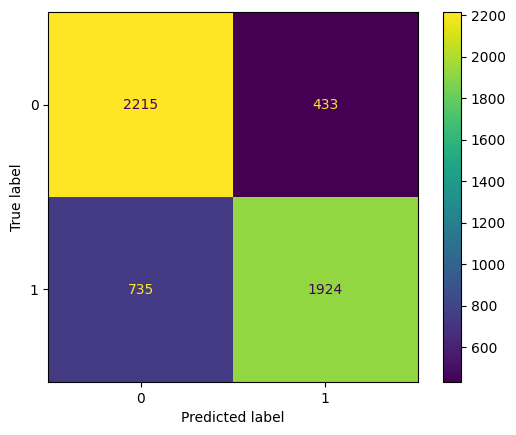

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Confusion matrix for SVC
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


this is a confusion matrix, in my opinion I think it is a easier to visual the classification report 

In [19]:
from sklearn.linear_model import SGDClassifier
clf_sgd = SGDClassifier(loss='hinge', random_state=SEED).fit(X, y)

In [20]:
#Classification report for SGDClassifier
y_pred_sgd = clf_sgd.predict(X_test)
print(classification_report(y_test, y_pred_sgd))

              precision    recall  f1-score   support

           0       0.80      0.74      0.77      2648
           1       0.76      0.82      0.79      2659

    accuracy                           0.78      5307
   macro avg       0.78      0.78      0.78      5307
weighted avg       0.78      0.78      0.78      5307



yikes accuracy of 53% is not looking too good...
looks like there is a trade off between memory and accuracy when comparing it to the SVC

Accuracy had a pretty big improvement when given the data set with it now having a 78% accuracy 

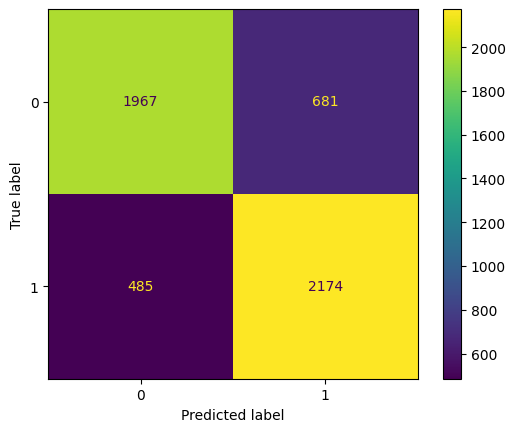

In [23]:
cmsgd = confusion_matrix(y_test, y_pred_sgd)
disp = ConfusionMatrixDisplay(confusion_matrix=cmsgd)
disp.plot()
plt.show()

hmm it seems to just classify everything as a nonpromoter... strange


another side note, I think I am going to need to use quiskit to do the QSVM so for now I am going to reproduce the memory calculations like how they do in the paper and go back to QSVM later

In [24]:
num_samples = X.shape[0]
feature_dim = X.shape[1]

 # Sparsity calculation -- looked at the imdb_svm.py file for this
row_sparsity = int(np.count_nonzero(X, axis=1).max())
col_sparsity = int(np.count_nonzero(X, axis=0).max())
sparsity = max(row_sparsity, col_sparsity)

#Space Calculations
space_stream = feature_dim
space_sparse = int(np.count_nonzero(X))

space_quantum = (
            2 * np.ceil(np.log2(num_samples + 2 * feature_dim))
            + np.ceil(np.log2(sparsity + 1))
            + 4
            )

print(f"Space (stream): {space_stream} bits")
print(f"Space (sparse): {space_sparse} bits")
print(f"Space (quantum): {space_quantum} qubits")

Space (stream): 256 bits
Space (sparse): 290068 bits
Space (quantum): 42.0 qubits


<function matplotlib.pyplot.show(close=None, block=None)>

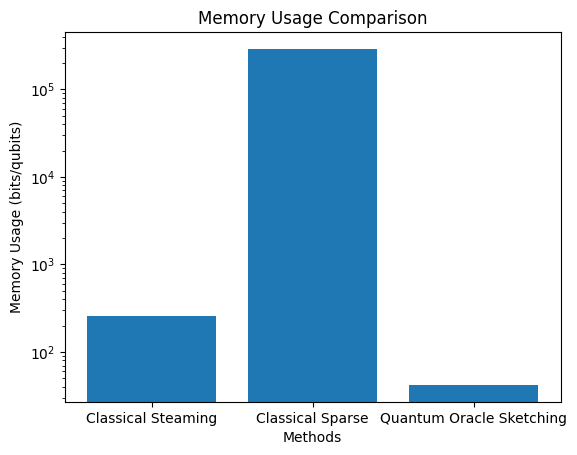

In [25]:
methods = ["Classical Steaming", "Classical Sparse", "Quantum Oracle Sketching"]
memory_values = [space_stream, space_sparse, space_quantum]

plt.bar(methods, memory_values)
plt.title("Memory Usage Comparison")
plt.xlabel("Methods")
plt.ylabel("Memory Usage (bits/qubits)")
plt.yscale('log') 
plt.show

Graph doesn't really show how the memory grows as more data grows like in the paper, but I guess I could change that later if I want to. Ask Ray what he would prefer, because certain graphs can kinda convey certain messages

In [80]:
import qsvt